                      Rainfall prediction using Linear regression                        

# Rainfall prediction using Linear regression

Predicting rainfall is a vital aspect of weather forecasting, agriculture planning and water resource management. In this article we will use Linear regression algorithm that help establish relationship between two variables i.e one dependent (rainfall) and one or more independent variables (temperature, humidity). It tells us how many inches of rainfall we can expect.

## Step 1: Importing Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Step 2: Data Collection and Loading

In [11]:
dataset = "https://raw.githubusercontent.com/itsluckysharma01/Datasets/refs/heads/main/Rainfall_dataset.csv"

df = pd.read_csv(dataset)

In [12]:
df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Austin,1/1/19,45.1,39.4,42.6,43.6,34.8,38.2,36.6,79.6,...,4.0,2,NaN,2019-01-01T07:27:35,2019-01-01T17:41:36,0.85,"Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"KATT,KAUS,72064800230,E4737,KEDC,72254013904,7..."
1,Austin,1/2/19,40.3,36.2,37.7,34.4,29.1,31.9,35.1,90.2,...,0.7,0,NaN,2019-01-02T07:27:48,2019-01-02T17:42:19,0.88,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"KATT,KAUS,72064800230,E4737,KEDC,72254013904,7..."
2,Austin,1/3/19,51.8,34.7,40.9,51.8,31.0,37.6,35.6,82.6,...,7.6,5,NaN,2019-01-03T07:28:00,2019-01-03T17:43:03,0.92,"Rain, Partially cloudy",Partly cloudy throughout the day with rain cle...,rain,"KATT,KAUS,72064800230,E4737,KEDC,72254013904,7..."
3,Austin,1/4/19,65.9,32.5,46.2,65.9,29.1,45.1,32.9,64.8,...,12.4,6,NaN,2019-01-04T07:28:10,2019-01-04T17:43:48,0.95,Clear,Clear conditions throughout the day.,clear-day,"KATT,KAUS,72064800230,E4737,KEDC,72254013904,7..."
4,Austin,1/5/19,73.7,37.5,52.3,73.7,36.2,52.2,35.5,58.6,...,12.7,6,NaN,2019-01-05T07:28:19,2019-01-05T17:44:34,0.00,Clear,Clear conditions throughout the day.,clear-day,"KATT,KAUS,72064800230,E4737,KEDC,72254013904,7..."


## Step 3: Data Preprocessing

In [13]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1664 non-null   object 
 1   datetime          1664 non-null   object 
 2   tempmax           1664 non-null   float64
 3   tempmin           1664 non-null   float64
 4   temp              1664 non-null   float64
 5   feelslikemax      1664 non-null   float64
 6   feelslikemin      1664 non-null   float64
 7   feelslike         1664 non-null   float64
 8   dew               1664 non-null   float64
 9   humidity          1664 non-null   float64
 10  precip            1664 non-null   float64
 11  precipprob        1664 non-null   int64  
 12  precipcover       1664 non-null   float64
 13  preciptype        641 non-null    object 
 14  snow              1664 non-null   float64
 15  snowdepth         1664 non-null   float64
 16  windgust          1453 non-null   float64


(1664, 33)

In [14]:
features = ['tempmax', 'tempmin', 'humidity', 'dew']
target = 'precip'
df = df.dropna(subset=features + [target])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1664 non-null   object 
 1   datetime          1664 non-null   object 
 2   tempmax           1664 non-null   float64
 3   tempmin           1664 non-null   float64
 4   temp              1664 non-null   float64
 5   feelslikemax      1664 non-null   float64
 6   feelslikemin      1664 non-null   float64
 7   feelslike         1664 non-null   float64
 8   dew               1664 non-null   float64
 9   humidity          1664 non-null   float64
 10  precip            1664 non-null   float64
 11  precipprob        1664 non-null   int64  
 12  precipcover       1664 non-null   float64
 13  preciptype        641 non-null    object 
 14  snow              1664 non-null   float64
 15  snowdepth         1664 non-null   float64
 16  windgust          1453 non-null   float64


In [16]:
df.isnull().sum()

name                   0
datetime               0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
preciptype          1023
snow                   0
snowdepth              0
windgust             211
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             0
solarradiation         0
solarenergy            0
uvindex                0
severerisk          1105
sunrise                0
sunset                 0
moonphase              0
conditions             0
description            0
icon                   0
stations               0
dtype: int64

## Step 4: Feature Selection

In [17]:
X = df[features]
y = df[target]

## Step 5: Model Training

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Step 6: Model Evaluation

In [24]:
y_pred = model.predict(X_test)

## Step 7: Prediction and Visualziing Results

Mean Squared Error: 0.04974770851826501
Root Mean Squared Error: 0.22304194340586483
R-squared: 0.16619844427894737


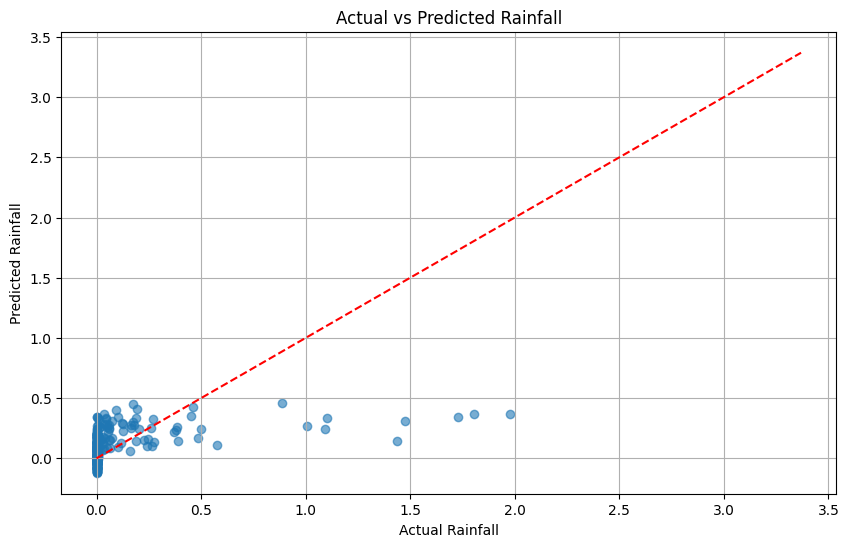

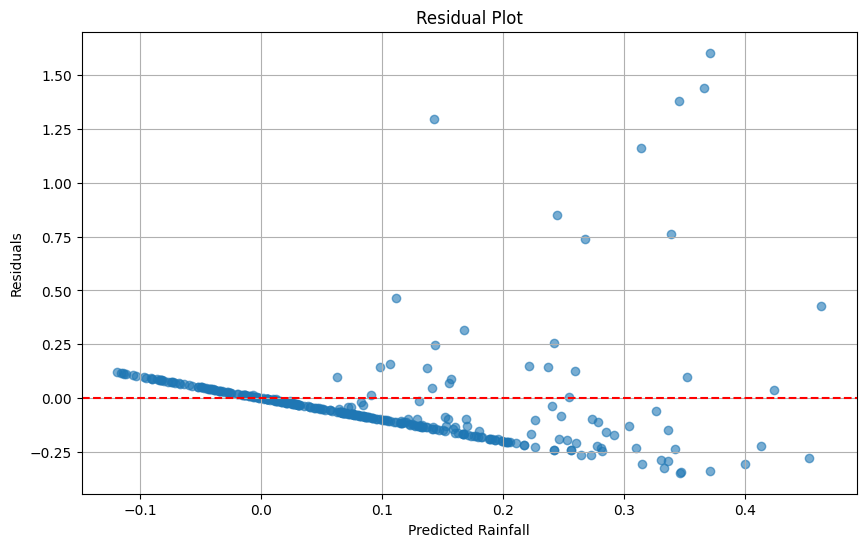

In [25]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Rainfall')
plt.xlabel('Actual Rainfall')
plt.ylabel('Predicted Rainfall')
plt.grid()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Rainfall')
plt.ylabel('Residuals')
plt.grid()
plt.show()

## Save The model


In [26]:
import pickle
import joblib
joblib.dump(model, 'rainfall_prediction_model.pkl')

['rainfall_prediction_model.pkl']